In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [5]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

### as_supervised: Indica que los datos se entreguen divididos en (Imagen, Etiqueta). Así la IA sabe qué imagen corresponde a qué prenda.

### with_info: Sirve para obtener información extra del dataset, como el nombre de las categorías (camisa, bota, etc.) y el número total de imágenes.


In [6]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\Leticia\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DB

In [7]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [8]:
nombres_clases = metadatos.features['label'].names

In [9]:
nombres_clases


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [10]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

In [11]:
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

# MAP
### Se utiliza para aplicar una misma operación a todos los elementos del dataset de forma automática.

### En este caso, se usa para normalizar las imágenes (convertir los píxeles de 0-255 a 0-1) para que la IA aprenda más rápido.

In [12]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

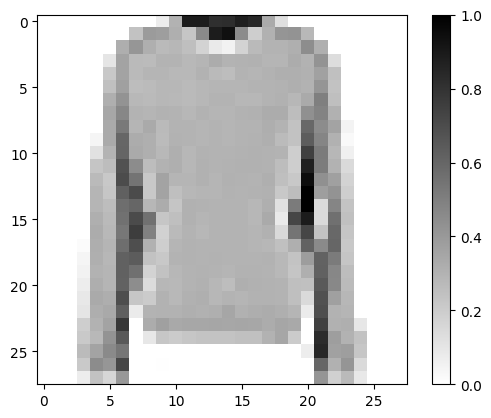

In [13]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28,28)) 

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()


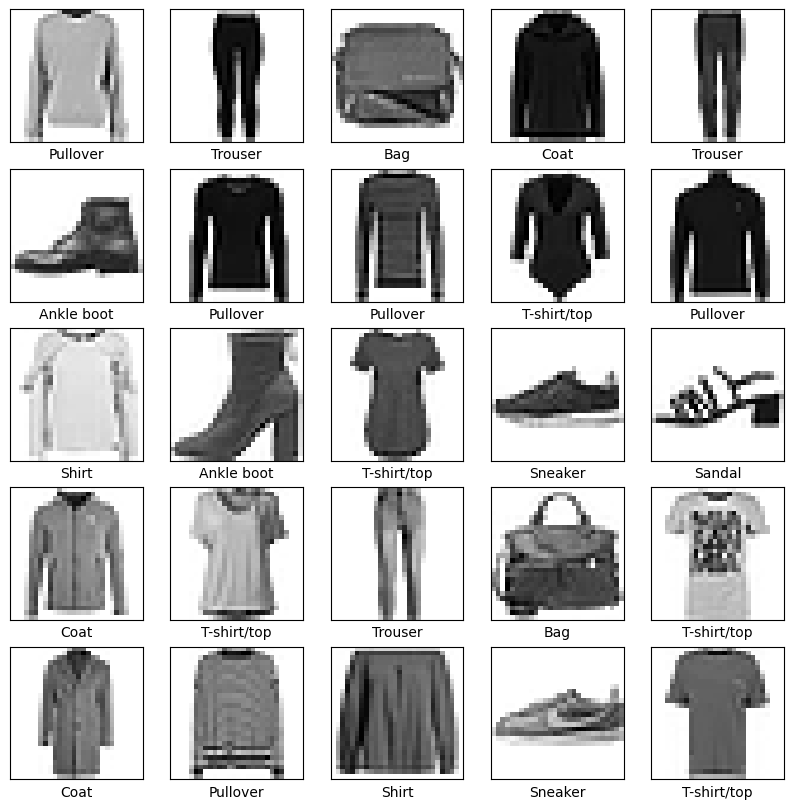

In [14]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [15]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax),
])

c:\Users\Leticia\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [17]:
TAMANO_LOTE = 32

In [18]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [19]:
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [20]:
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8188 - loss: 0.5124
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8612 - loss: 0.3822
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8750 - loss: 0.3429
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8810 - loss: 0.3246
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8876 - loss: 0.3029


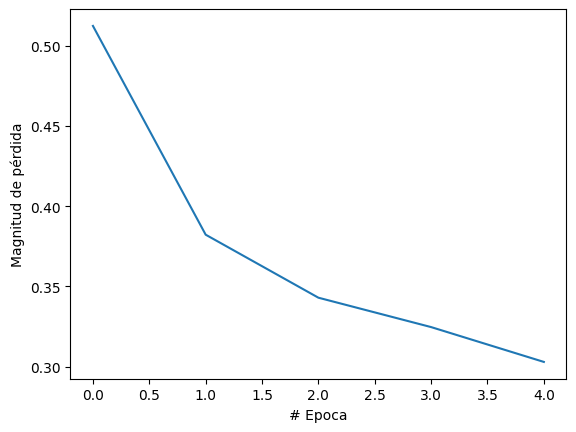

In [21]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

In [22]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion], 100*np.max(arr_predicciones), nombres_clases[etiqueta_real]), color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Prediccion: T-shirt/top


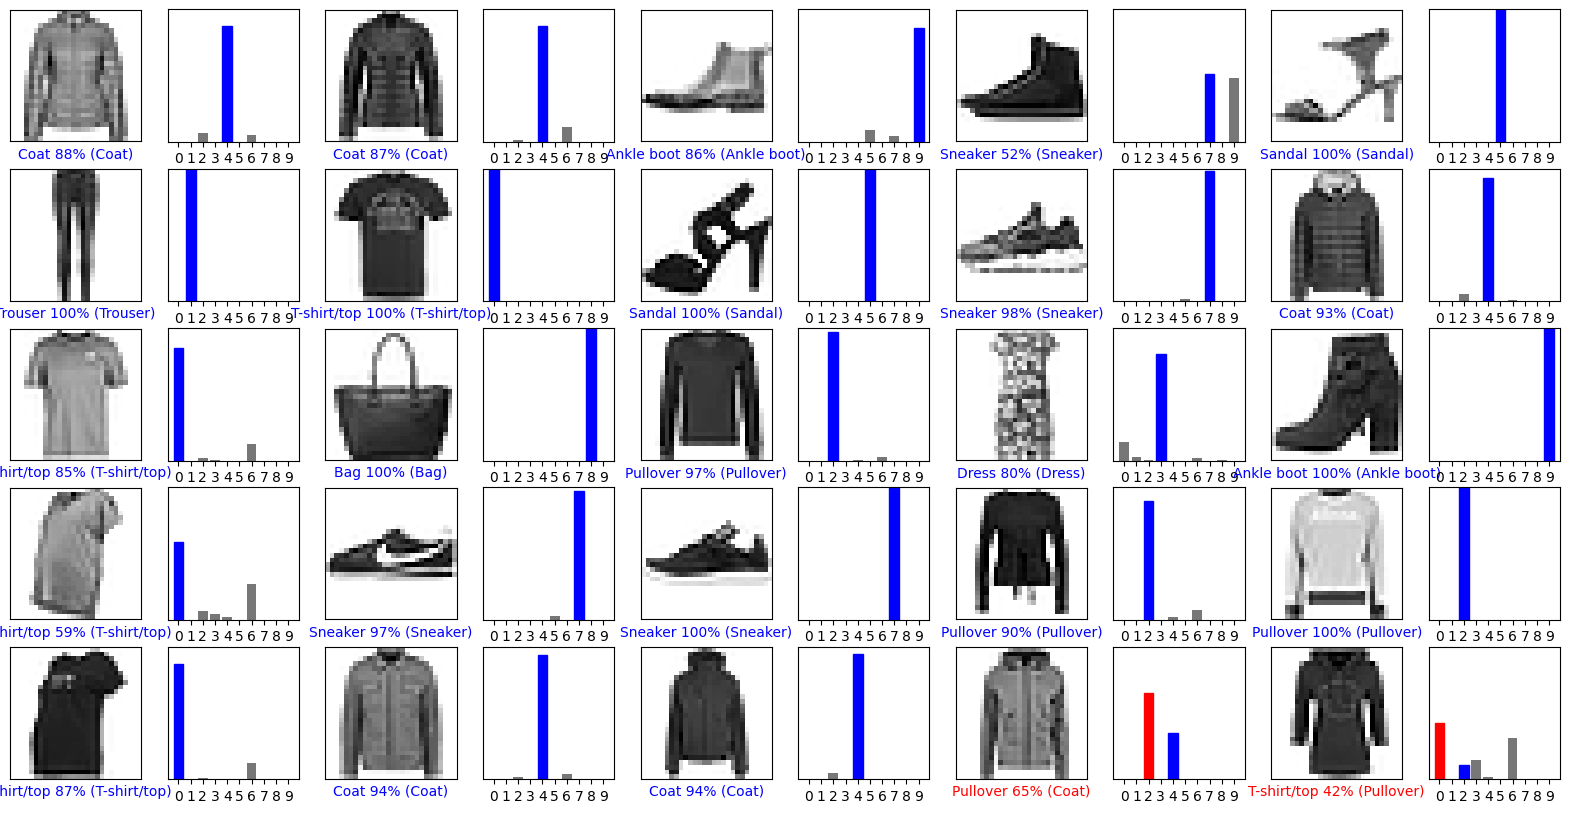

In [23]:
def graficar_valor_arreglo(i, arr_predicciones, etiquetas_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiquetas_real[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    
    # Dibuja las barras de predicción en gris
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    
    etiqueta_prediccion = np.argmax(arr_predicciones)
    
    # Si falló es rojo, si acertó es azul
    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

# --- CONFIGURACIÓN DE LA CUADRÍCULA DE PRUEBA ---

filas = 5
columnas = 5
num_imagenes = filas * columnas

plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
    # Lado izquierdo: La foto de la prenda
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    
    # Lado derecho: La gráfica de barras de probabilidad
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)


# --- REALIZAR PREDICCIÓN DE UNA IMAGEN INDIVIDUAL (Página final del PDF) ---

imagen = imagenes_prueba[24] # Tomamos la imagen número 24
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

# Que es el formato .h5?
### Es un formato de archivo llamado Hierarchical Data Format v5.
### En Inteligencia Artificial, se usa para almacenar modelos completos. Guarda tanto la estructura de la red (las capas) como los "pesos" (lo que la IA aprendió tras entrenar). Esto permite que puedas usar tu modelo en otro programa o página web sin tener que entrenarlo de nuevo desde cero.

In [ ]:
import tkinter as tk
from tkinter import filedialog
from PIL import Image

# --- 4. EXPORTAR EL MODELO A .H5 ---
modelo.save('modelo_TiendaDeRopa.h5')
print("Modelo guardado como 'modelo_TiendaDeRopa.h5'")

# --- 2. CÓDIGO INTERACTIVO PARA CARGAR IMAGEN ---
def clasificar_mi_imagen():
    # Abrir ventana para elegir archivo
    root = tk.Tk()
    root.withdraw()
    ruta_imagen = filedialog.askopenfilename()
    
    if ruta_imagen:
        # Procesar la imagen para que sea de 28x28 y blanco y negro
        img = Image.open(ruta_imagen).convert('L').resize((28, 28))
        img_array = np.array(img)
        
        # Invertir colores si es necesario (FashionMNIST usa fondo negro)
        img_array = 255 - img_array 
        img_array = img_array / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        # Predicción
        prediccion = modelo.predict(img_array)
        clase_final = nombres_clases[np.argmax(prediccion[0])]
        
        print(f"\n--- RESULTADO INTERACTIVO ---")
        print(f"La IA cree que tu imagen es: {clase_final}")
        
        # Mostrar la imagen que subiste
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicción: {clase_final}")
        plt.show()

# Llamar a la función interactiva
clasificar_mi_imagen()

Modelo guardado como 'modelo_TiendaDeRopa.h5'
